In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale = 1.0/255,
    rotation_range = 20,
    width_shift_range = 0.20,
    height_shift_range = 0.20,
    horizontal_flip = True,
    zoom_range = 0.2,
    shear_range = 0.15,
    fill_mode = 'nearest'
)

val_datagen = ImageDataGenerator(
    rescale = 1.0/255
)

In [2]:
train = train_datagen.flow_from_directory(
   'cat_dog_dataset/train' ,
   target_size = (64,64),
   batch_size = 32,
   class_mode = 'binary'
)

val = val_datagen.flow_from_directory(
   'cat_dog_dataset/val' ,
   target_size = (64,64),
   batch_size = 32,
   class_mode = 'binary'
)

Found 23938 images belonging to 2 classes.
Found 1062 images belonging to 2 classes.


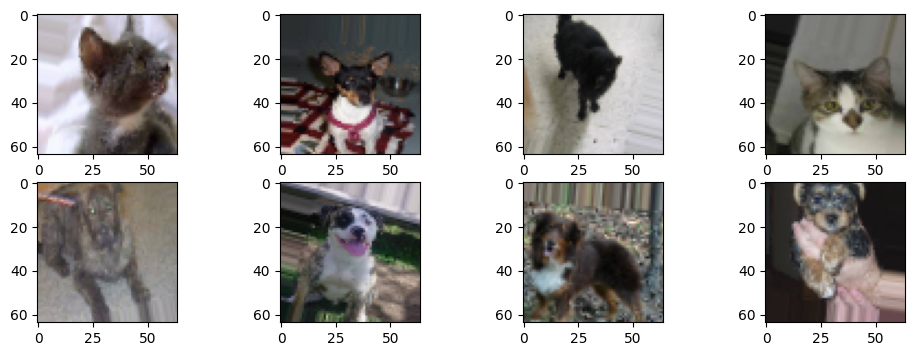

In [3]:
import matplotlib.pyplot as plt
imgs, labels = next(train)

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(imgs[i])

plt.show()

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

c:\Users\visha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [6]:
model.fit(train, validation_data=val, epochs=10)

Epoch 1/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 427s 568ms/step - accuracy: 0.6138 - loss: 0.6474 - val_accuracy: 0.7156 - val_loss: 0.5567
Epoch 2/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 61s 82ms/step - accuracy: 0.6803 - loss: 0.5945 - val_accuracy: 0.7495 - val_loss: 0.5228
Epoch 3/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 60s 80ms/step - accuracy: 0.7080 - loss: 0.5605 - val_accuracy: 0.7514 - val_loss: 0.4981
Epoch 4/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 64s 85ms/step - accuracy: 0.7263 - loss: 0.5369 - val_accuracy: 0.7863 - val_loss: 0.4621
Epoch 5/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 59s 78ms/step - accuracy: 0.7433 - loss: 0.5175 - val_accuracy: 0.7957 - val_loss: 0.4496
Epoch 6/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - accuracy: 0.7530 - loss: 0.5051 - val_accuracy: 0.8023 - val_loss: 0.4309
Epoch 7/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 58s 77ms/step - accuracy: 0.7608 - loss: 0.4896 - val_accuracy: 0.7938 - val_loss: 0.4180
Epoch 8/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 59s 79ms/step - accuracy: 0.7691 - loss: 0.4779 

In [14]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

path1 = 'cat_dog_dataset/val/dogs/dog.521.jpg'
path = 'catimage/train/cats/cat.531.jpg'
img = load_img(path, target_size=(64,64))
x = img_to_array(img) / 255.0
x = np.expand_dims(x, axis=0)

result = model.predict(x)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


Cat


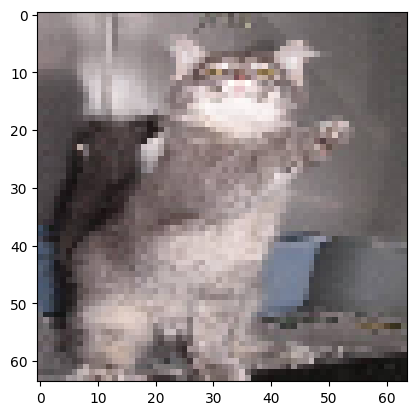

In [ ]:
if result > 0.5:
    print("Dog")
else:
    print("Cat")

plt.imshow(img)
plt.show()